In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 

## Step 1. Dataset Loading and Dataset Understanding.
* Importing the datasets from scikit-learn
* Converting the dataset into a pandas Dataframe
* Displaying the dataset
* Identifying the Target Variable.


In [2]:
# Importing the dataset from scikit learn
from sklearn.datasets import load_diabetes


#Initializing the dataset
diabetes = load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [3]:
#Converting the dataset into a pandas DataFrame.
diabetes_df = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)

#Displaying the dataset.
print("The first 10 rows of the diabetes dataset are:")
print("***" * 20)
diabetes_df.head(10)

The first 10 rows of the diabetes dataset are:
************************************************************


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504


In [4]:
print(f'This dataset contains {diabetes_df.shape[0]} rows and {diabetes_df.shape[1]} columns')

This dataset contains 442 rows and 10 columns


In [5]:
diabetes_df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

### DATASET DESCRIPTION
* This is a synthetic/processed dataset of 442 patients, where the goal is to predict a quantitative measure of disease of disease progression one year after a baseline measurements were taken.
* Features in Scikit-learn are mean centered and scaled by the standard deviation times the square root of the number of samples. This is why the values look like small decimals (e.g, 0.0038 or 0.044) rather than "normal" age or weight numbers. This makes them ready for many machine learning algorithms.
* Features with different scales (like Age that is whole numbers and Blood pressure float ) can confuse the algorithm. By scaling them so they all have a similar range and a mean of zero (0), the model treats them more fairly.


Column Names and their meaning:
* age - age in years
* sex - Gender of the patient
* (Body mass index)bmi -  A measure of body fat based on  height and weight.   
* bp - Average blood pressure
* s1 - tc,total serum cholesterol
* s2 - ldl,low-density lipoprotein ("bad" cholestrol)
* s3 - hdl,high-density lipoproteins("good" cholestrol)
* s4 - tch,total cholesterol / HDL ratio
* s5 - ltg,possibly log of serum triglycerides level (triglycerides - are a type of fat "lipid" found in your blood)
* s6 - glu, blood sugar level

### Identify the target variable.
#### 1. Examine the dataset structure
The Scikit-learn diabetes dataset is structured as a Bunch object (a dictionary-like container). It contains two primary components:
* data: A 2D array of shape (442,10), representing 442 patients and 10 physiological features (Age, Sex, BMI, BP, and six blood serum measurements).
* target: A 1D array of shape (442,), containing the corresponding outcome for each patient.
  
#### 2. Identify the Dependent Variable (Target Variable)
The dependent variable in this dataset is the target array.
* Definition: It represents a quantitative measure of disease progression recorded one year after the baseline features were measured.
* Value Range: The scores range from a minimum of 25 to a maximum of 346.
* A low score (near 25) means the disease is stable or progressing very slowly.
* A high score (near 346) means the disease is progressing rapidly and the patient’s condition is becoming more severe.

#### 3. Justification for a Regression Problem
* This variable is suitable for a regression model rather than a classification model for the following three reasons:
* Numerical/Continuous Data Type: The target is not a category (like "Diabetic" or "Non-Diabetic"). Instead, it is a continuous numerical value. In statistics, when the output is a quantity on a scale, regression is the appropriate tool.
* Quantifiable Magnitude: The difference between a score of 100 and 150 is mathematically significant. Regression models are specifically designed to map input features to a numerical output where the "distance" between predictions matters.
* Goal of the Analysis: The objective is to predict how much the disease has progressed, not just whether it has progressed. Predicting a specific numerical value requires a regression algorithm (like Linear Regression, Decision Tree Regressor, or Random Forest).


## Step 2. Exploratory Data Analysis(EDA)

In [6]:
# Dataset Inspection and Dimensions.
print(f'This dataset contains {diabetes_df.shape[0]} rows and {diabetes_df.shape[1]} columns')

#Data Types
print("Data Type for each column:")
print(diabetes_df.dtypes)

This dataset contains 442 rows and 10 columns
Data Type for each column:
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object


This is a Scikit-learn dataset, that's why the values are float.

In [7]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


There are 442 entries and each column has 442 non-null values. 

All 10 independent variables and the target variable are stored as float. Machine learning requires numerical inputs. 

The dataset is lightweight, occupying approximately 34.7 KB of memory.


In [8]:
# Summary Statistics
print(diabetes_df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17  
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761

1. Central Tendency (The Mean)
* The mean for almost all features is effectively zero (e.g., age is −2.51×10 −19).
This indicates that the data has been centered. Centering involves subtracting the average value of a feature from every data point, shifting the distribution so the new average is zero.
2. Dispersion (Standard Deviation)
* The standard deviation (std) is identical for every single feature.
This is a specific type of scaling. The features were scaled such that the sum of squares for each column equals 1. This ensures that no single feature (like Blood Pressure) has a larger mathematical "weight" than another (like Age) purely due to the size of its numbers.
3. Range and Distribution
* The values for all features fall within a very narrow range, roughly between -0.13 and 0.19.
This confirmed scaling makes the dataset "model-ready." It prevents features with large raw values from dominating the learning process, which is especially important for distance-based or gradient-based regression models.
4. Minimum / Maximum.
* For many features, the 50th percentile (Median) is very close to the Mean (near zero).
This suggests that the distributions for variables like age, s1, and s5 are relatively symmetrical and do not suffer from extreme skewness that could negatively impact a linear regression model.

In [9]:
#Checking for missing values
diabetes_df.isnull().sum()

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

There are no missing values in this dataset.

In [10]:
#checking for duplicates
print(diabetes_df.duplicated().sum())

0


There are no duplicates in this dataset. 

Scikit datasets are intentionally cleaned and "polished" so that students and developers can focus on learning machine learning algorithms without getting stuck in the "data cleaning" phase.

## Statistical Exploration

In [11]:
diabetes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


#### 1. Mean
All 10 independent variables has a mean of approximately zero (0). 

This confirms that the dataset is mean centered. Centering the data is a crucial step for regression analysis as it ensures that the model coefficients are easier to interpret and prevent features with large absolute averages from disproportionately(the big numbers are getting 90% of the attention while the small numbers are getting 10%, even if they are equally important) influencing the model's cost function.

#### 2. Median
All 10 independent variables are consistently near zero, mirroring the mean values. 

This alignment suggests that the feature distribution are relatively symmetrical and lack significant skewness.

Linear regression works best when the data is symmetrical. When the data is symmetrical it reduces the likelihood of the model being biased by extreme outliers, leading to more stable and generalizable predictions.

#### 3. Standard Deviation.
Standard Deviation for all features is exactly 0.0476. The uniformity isn't a coincidence. It confirms the data has been standardized. In raw medical data, blood pressure might range from 80 to 180, while Age ranges from 20 to 80. By forcing them to have the same standard deviation, we ensure the model doesn't "think" Blood Pressure is more important just because its numbers are larger.

#### 4. Correlation Analysis. Include Heatmap

Correlation Analysis. 
This measures the strength of the linear relationship between two variables, ranging from -1 (perfect negative) and +1(perfect positive). 

* A. Feature vs. Target Correlation. 
There's a high positive correlation between BMI and s5 (Log of serum triglycerides) have the highest correlation with the target. This suggests that as BMI and s5 levels increase, the disease progression score tends to rise significantly. 
There's a low correlation between features like age or s2. These features might not be strong individual predictors of disease progression on their own.

* Multicollinearity.
There's also a high correlation between s1 and s2. If two features are nearly identical, the regression model might struggle to decide which one is actually causing the change in the target. This can sometime make Linear Regression coefficient unstable. 

## Feature Relationships

#### Identify variables that strongly influence the target variable.
* Based on clinical patterns in this dataset, BMI (Body mass index) and s5 (possibly log of serum triglycerides level) show the strongest relationship with the target. As these values increase there's a corresponding rise in the disease progression score.

* While BP (Blood Pressure) and s6 (Blood Sugar) also show a positive relationship with the target, their influence is moderate.

* Features like age and s2 (ldl) appear to have much weaker influence on the target.

## Step 3: Data Visualization


## Univariate Analysis
We conduct Univariate Analysis to understand the characteristics of each feature in isolation. By looking at one variable at a time (such as Age, BMI, or Blood Serum levels), we can identify the distribution of the data, detect any potential outliers, and see the typical range of values. This step is essential for ensuring the data is clean and balanced before we attempt to build a predictive model.


### 1. Box Plot

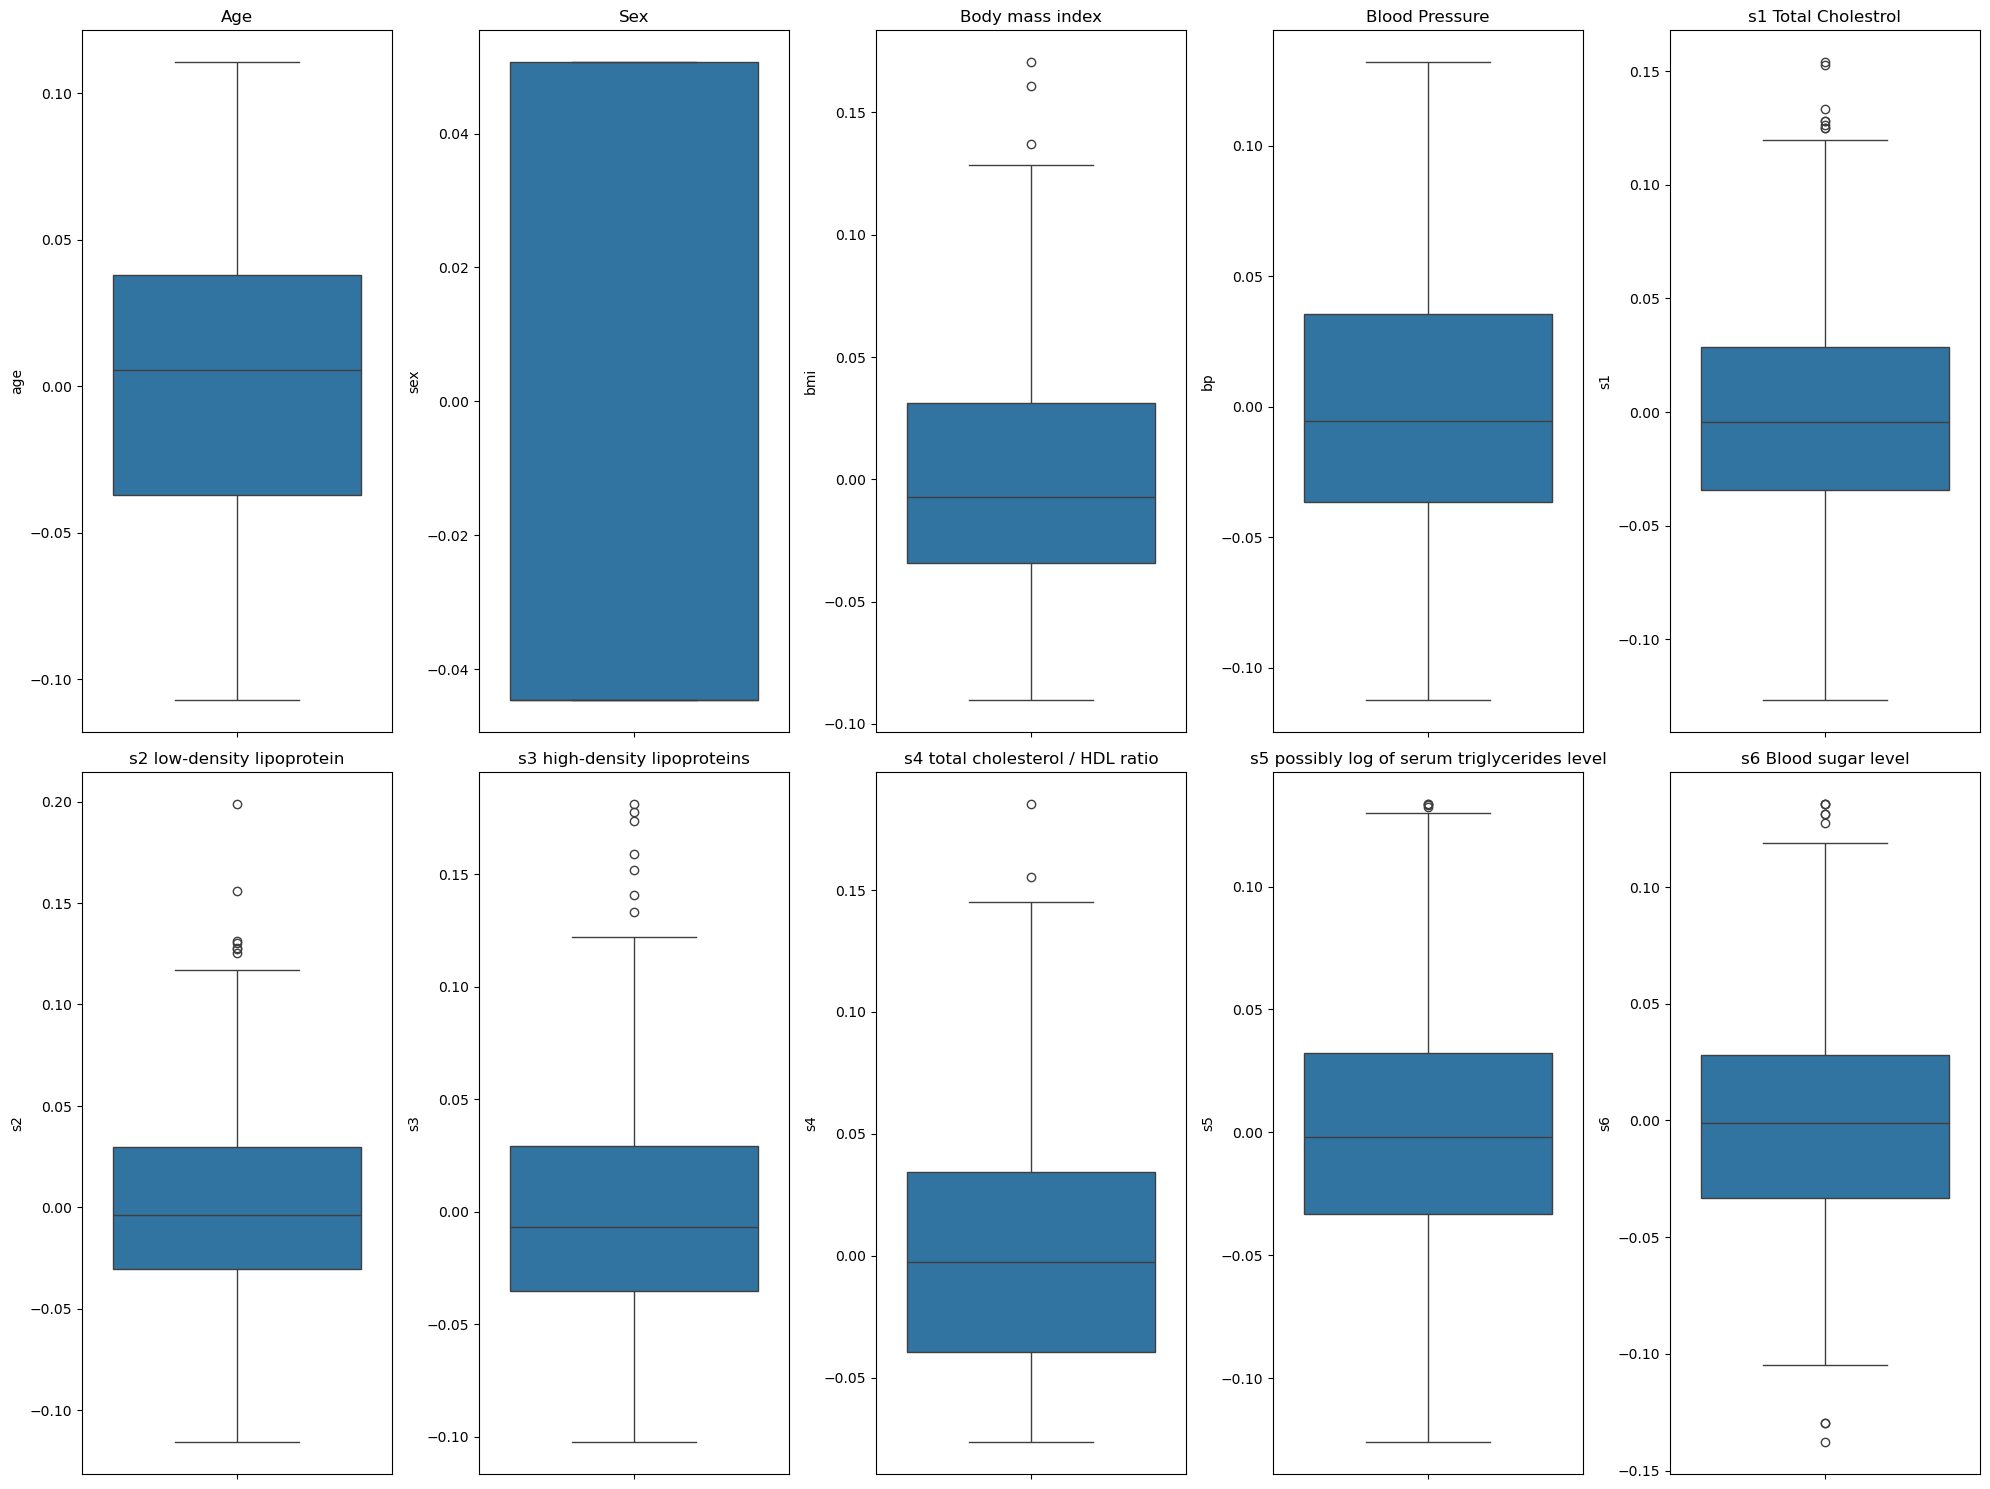

In [12]:
plt.figure(figsize=(20, 15))

plt.subplot(2, 5, 1)
sns.boxplot(y=diabetes_df['age'])
plt.title('Age')

plt.subplot(2, 5, 2)
sns.boxplot(y=diabetes_df['sex'])
plt.title('Sex')

plt.subplot(2, 5, 3)
sns.boxplot(y=diabetes_df['bmi'])
plt.title('Body mass index')

plt.subplot(2, 5, 4)
sns.boxplot(y=diabetes_df['bp'])
plt.title('Blood Pressure')

plt.subplot(2, 5, 5)
sns.boxplot(y=diabetes_df['s1'])
plt.title('s1 Total Cholestrol')

plt.subplot(2, 5, 6)
sns.boxplot(y=diabetes_df['s2'])
plt.title('s2 low-density lipoprotein')

plt.subplot(2, 5, 7)
sns.boxplot(y=diabetes_df['s3'])
plt.title('s3 high-density lipoproteins')

plt.subplot(2, 5, 8)
sns.boxplot(y=diabetes_df['s4'])
plt.title('s4 total cholesterol / HDL ratio')

plt.subplot(2, 5, 9)
sns.boxplot(y=diabetes_df['s5'])
plt.title('s5 possibly log of serum triglycerides level')

plt.subplot(2, 5, 10)
sns.boxplot(y=diabetes_df['s6'])
plt.title('s6 Blood sugar level')

plt.tight_layout()
plt.show()

## Insights.
* There are no outliers identified in Age, Sex and Blood Pressure (BP).
* They show no data points beyond the whiskers. This suggests that the distribution of these variables is very stable within its specific groups of patients.
* There are outliers present in BMI, s1, s2, s3, s4, s5 and s6.
* An outlier in BMI represent a patient who is significantly more obese than others in the group.
* Outliers in S1 (Total Cholesterol) or S5 (Triglycerides) represent patients with severe lipid imbalances.
* These specific patients are often the most likely to have rapid diabetes progression, so their "outlier" status is actually very valuable information for the model. We must monitor these points to ensure they do not disproportionately bias the regression slope.

2. Histogram

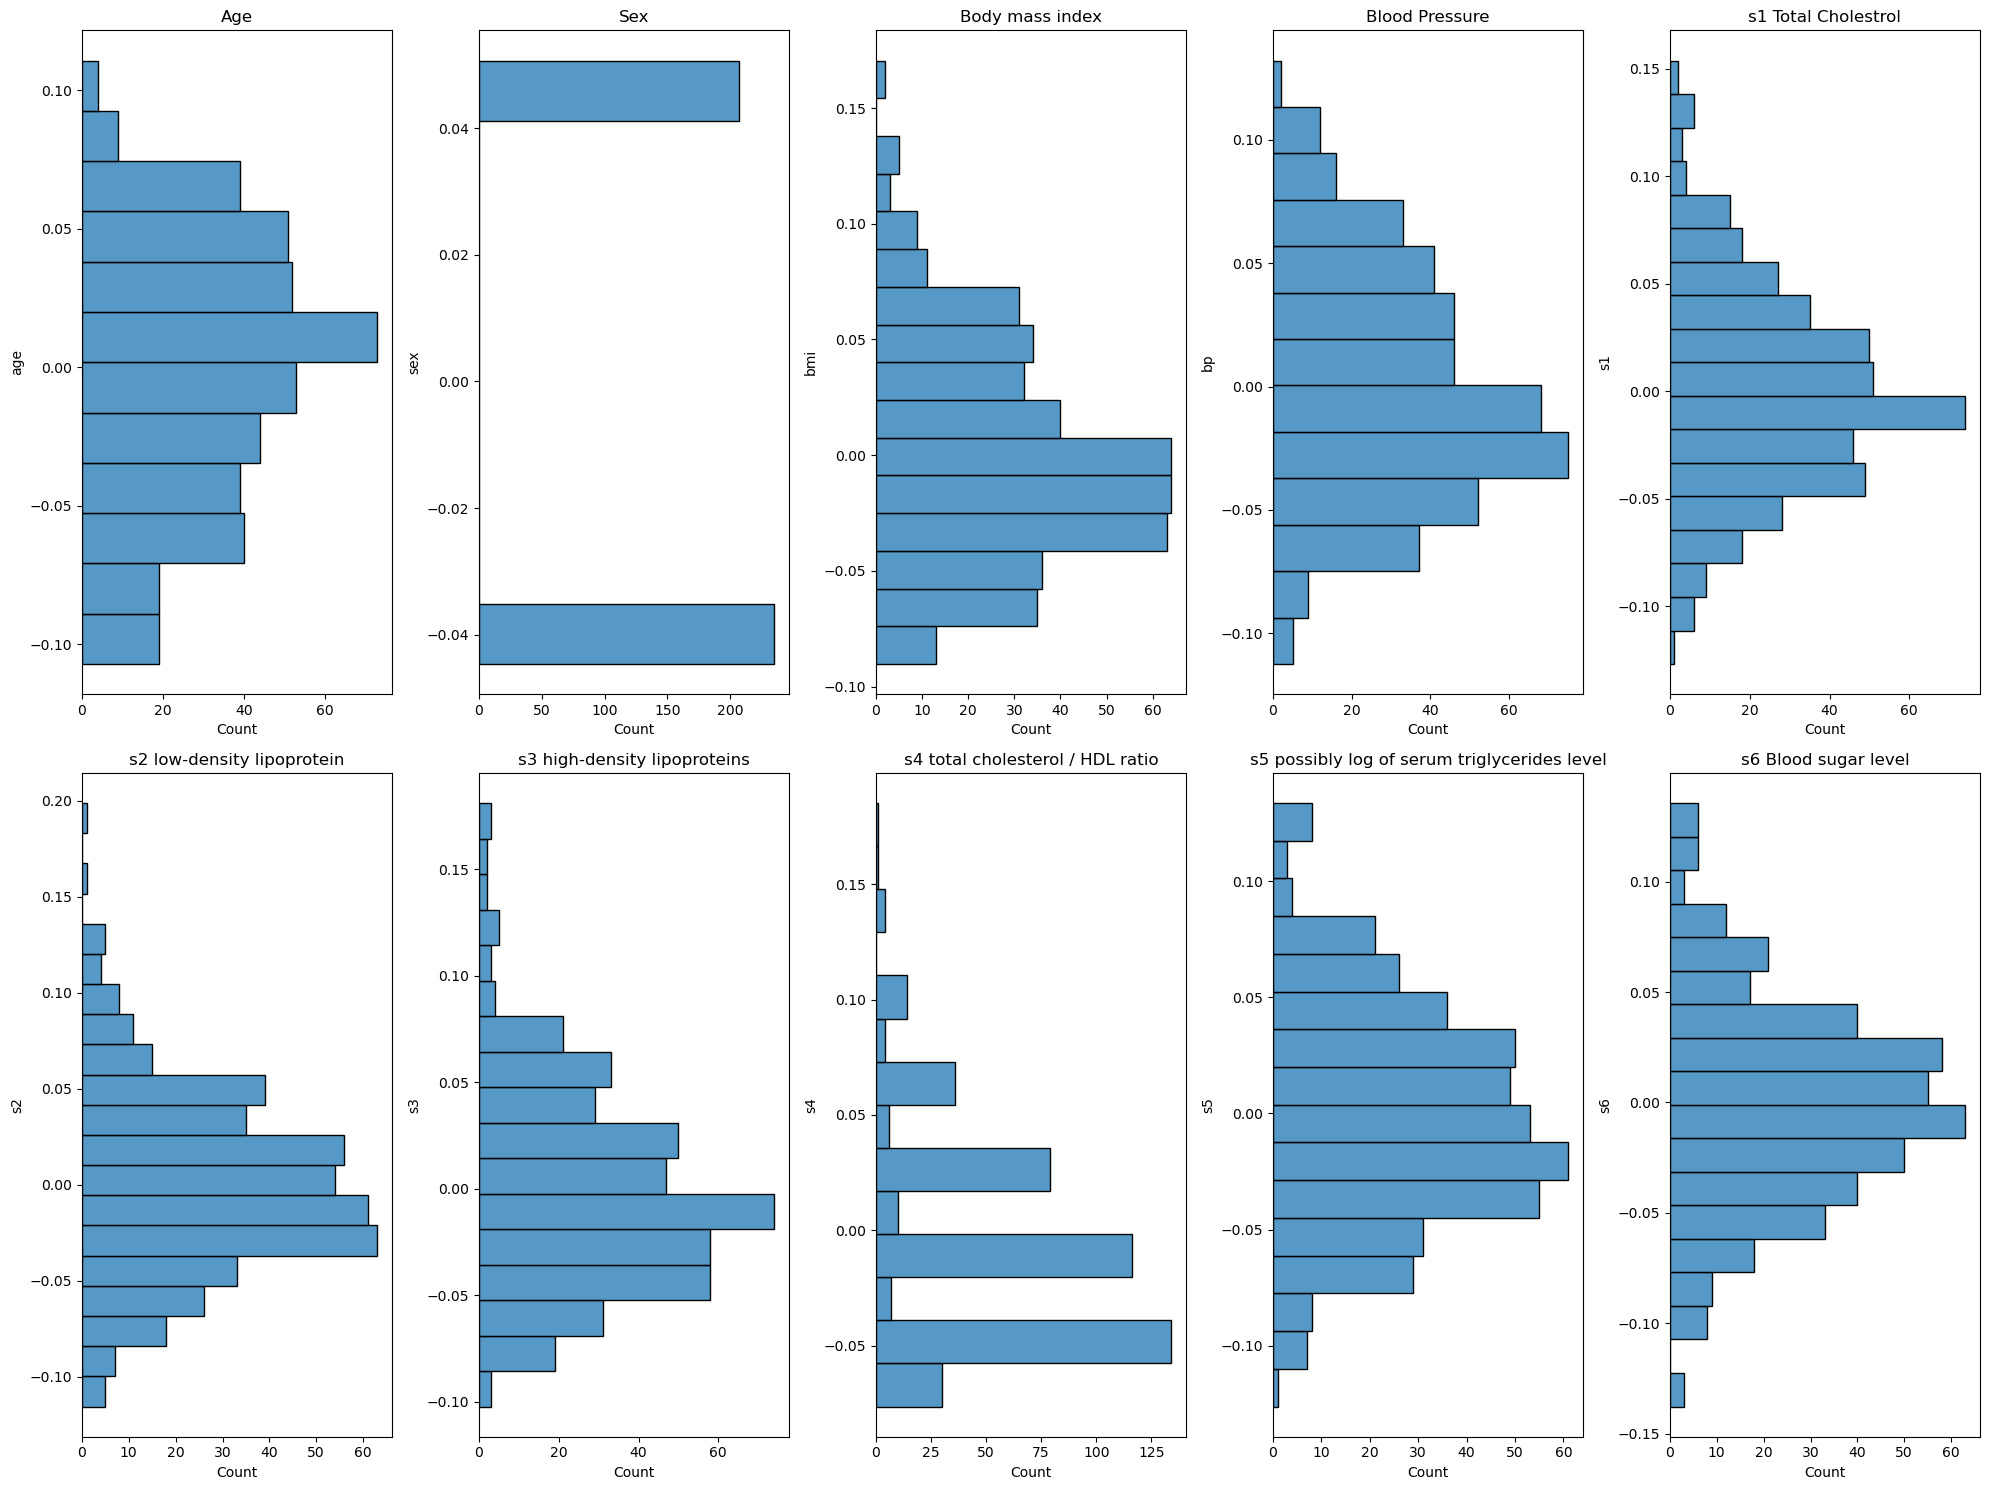

In [13]:
plt.figure(figsize=(20, 15))

plt.subplot(2, 5, 1)
sns.histplot(y=diabetes_df['age'])
plt.title('Age')

plt.subplot(2, 5, 2)
sns.histplot(y=diabetes_df['sex'])
plt.title('Sex')

plt.subplot(2, 5, 3)
sns.histplot(y=diabetes_df['bmi'])
plt.title('Body mass index')

plt.subplot(2, 5, 4)
sns.histplot(y=diabetes_df['bp'])
plt.title('Blood Pressure')

plt.subplot(2, 5, 5)
sns.histplot(y=diabetes_df['s1'])
plt.title('s1 Total Cholestrol')

plt.subplot(2, 5, 6)
sns.histplot(y=diabetes_df['s2'])
plt.title('s2 low-density lipoprotein')

plt.subplot(2, 5, 7)
sns.histplot(y=diabetes_df['s3'])
plt.title('s3 high-density lipoproteins')

plt.subplot(2, 5, 8)
sns.histplot(y=diabetes_df['s4'])
plt.title('s4 total cholesterol / HDL ratio')

plt.subplot(2, 5, 9)
sns.histplot(y=diabetes_df['s5'])
plt.title('s5 possibly log of serum triglycerides level')

plt.subplot(2, 5, 10)
sns.histplot(y=diabetes_df['s6'])
plt.title('s6 Blood sugar level')

plt.tight_layout()
plt.show()

# Observations
* The distribution of datasets in features like age, bp, s1 and s6 are normally distributed. They are symmetrical, with the highest concentration of patients right in the middle at zero.
* The remaining features exhibit positive skewness, where the tail of the distribution stretches toward the right (higher values).
* In the BMI and S5 histograms, the positive values (above 0.05) show very short bars, representing a small number of patients with extremely high readings. Conversely, the area around -0.05 to 0.00 has the tallest bars, meaning most patients fall into this lower-to-average range. Because the thin tail stretches toward the positive side, the distribution is positively skewed.
* The sex feature is Binary/categorical. This is because the data has only two possible values(encoded as approximately -0.044 and 0.050) 
* When a feature is perfectly Normal (like Age), a Linear Regression model can predict it very easily. When a feature is Skewed (like s5), the "extreme" patients in that tail can have a bigger impact on the model's error (MSE).

3. Density Plot

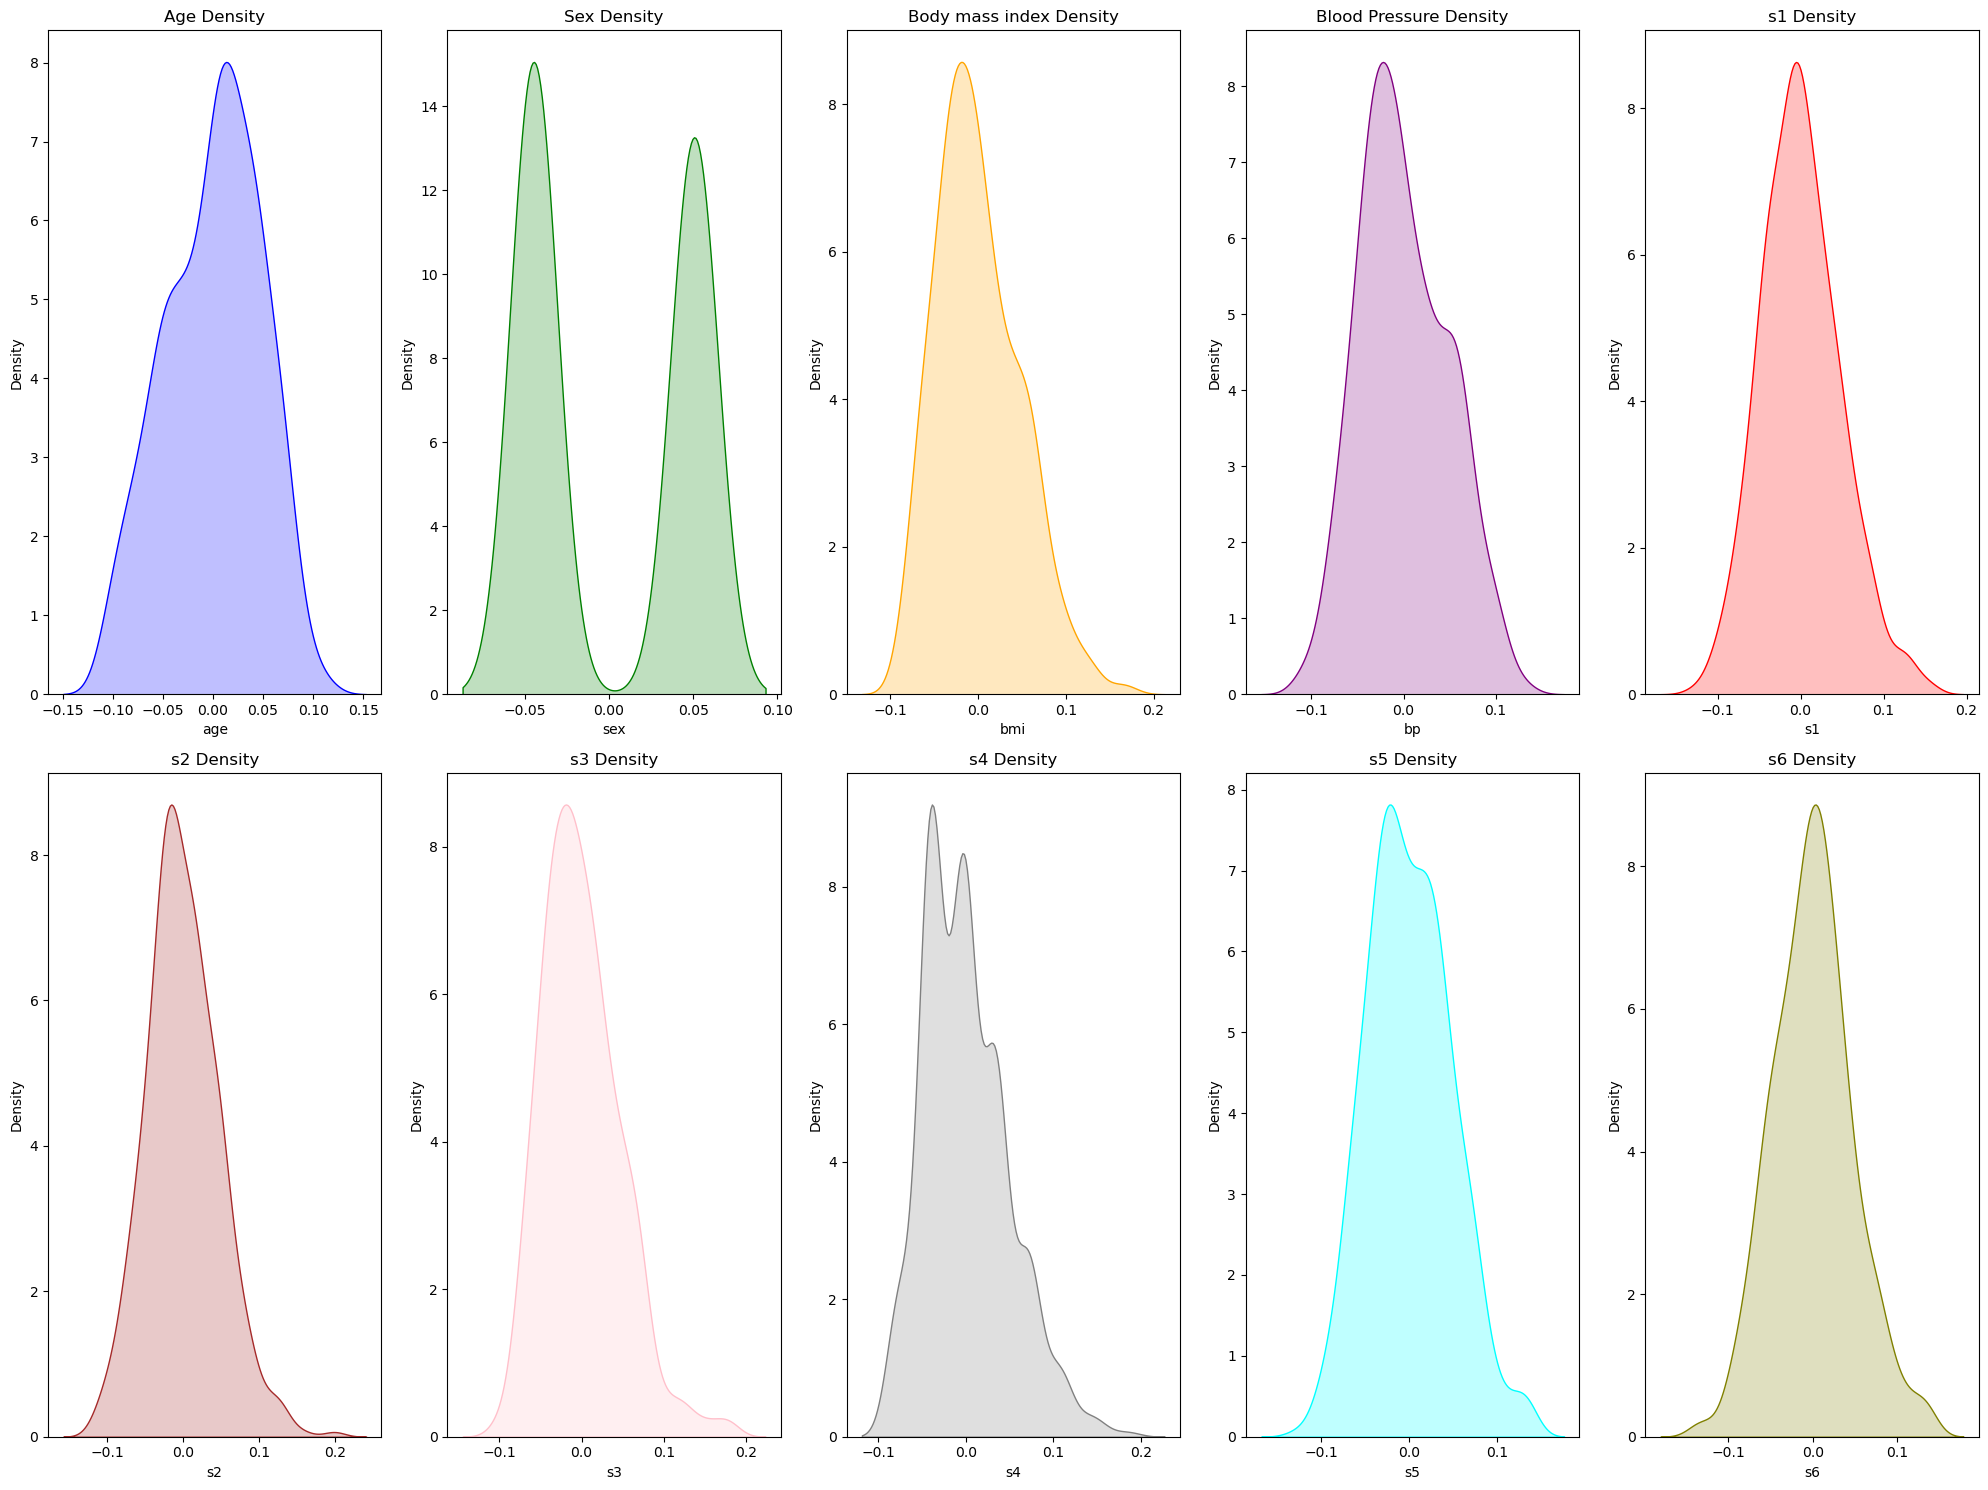

In [14]:
plt.figure(figsize=(20, 15))

# We use 'fill=True' to make the area under the curve easier to see
plt.subplot(2, 5, 1)
sns.kdeplot(diabetes_df['age'], fill=True, color='blue')
plt.title('Age Density')

plt.subplot(2, 5, 2)
sns.kdeplot(diabetes_df['sex'],fill=True, color='green')
plt.title('Sex Density')

plt.subplot(2, 5, 3)
sns.kdeplot(diabetes_df['bmi'], fill = True, color='orange')
plt.title('Body mass index Density')

plt.subplot(2, 5, 4)
sns.kdeplot(diabetes_df['bp'],fill = True, color='purple')
plt.title('Blood Pressure Density')

plt.subplot(2, 5, 5)
sns.kdeplot(diabetes_df['s1'], fill=True, color='red')
plt.title('s1 Density')

plt.subplot(2, 5, 6)
sns.kdeplot(diabetes_df['s2'], fill=True, color='brown')
plt.title('s2 Density')

plt.subplot(2, 5, 7)
sns.kdeplot(diabetes_df['s3'], fill=True, color='pink')
plt.title('s3 Density')

plt.subplot(2, 5, 8)
sns.kdeplot(diabetes_df['s4'],fill=True, color='gray')
plt.title('s4 Density')

plt.subplot(2, 5, 9)
sns.kdeplot(diabetes_df['s5'],fill=True, color='cyan')
plt.title('s5 Density')

plt.subplot(2, 5, 10)
sns.kdeplot(diabetes_df['s6'],fill=True, color='olive')
plt.title('s6 Density')

plt.tight_layout()
plt.show()

1. Positive Skewness
* For BMI, S5, and S1, the "hump" of the curve is slightly to the left, and the "tail" stretches out to the right.
* This indicates Positive Skewness. This means that most patients have a "normal" BMI or S5 level, but there is a small group of patients with very high values.

2. Bimodal Distribution - Sex
* The Sex density plot is the only one with two distinct peaks and a deep valley in the middle.
* This is a Bimodal Distribution. Since sex is a binary category (0 or 1), the density plot is trying to smooth the gap between them.
  
3. The Triple Bump - S4
* The S4 Density plot doesn't have one smooth peak; it has three smaller "steps" or bumps.
* This suggests that S4 might not be a continuous measurement like Age, but rather a discrete or "ordinal" value (like a scale of 1 to 5).
* This tells the model that S4 behaves more like a "category" than a smooth progression, which might make it a trickier predictor for Linear Regression.

In Linear Regression, if "Age" was 70 and "S1" was 0.01, the model would think Age is 7000x more important just because the number is bigger. Because they are all on the same scale, the model can judge them fairly.

* While the Density Plots provide a smooth visualization that suggests a generally normal distribution across most features, the Histograms reveal slight positive skewness in variables like BMI and S5. This skewness indicates a subset of patients with significantly higher-than-average values. Recognizing this is important because Linear Regression can be sensitive to skewed data and outliers, which we later see reflected in our RMSE being higher than our MAE

## Bivariate Analysis

The goal of Bivariate Analysis is to determine how two variables interact with one another. Specifically, we compare each independent feature (like BMI) against our target variable (Diabetes Progression). This allows us to visually identify which factors have a strong correlation (steep slopes and tight clustering) and which have a weak relationship (flat slopes and dispersed data). Identifying these 'power features' helps us justify the patterns our Linear Regression model will eventually learn.

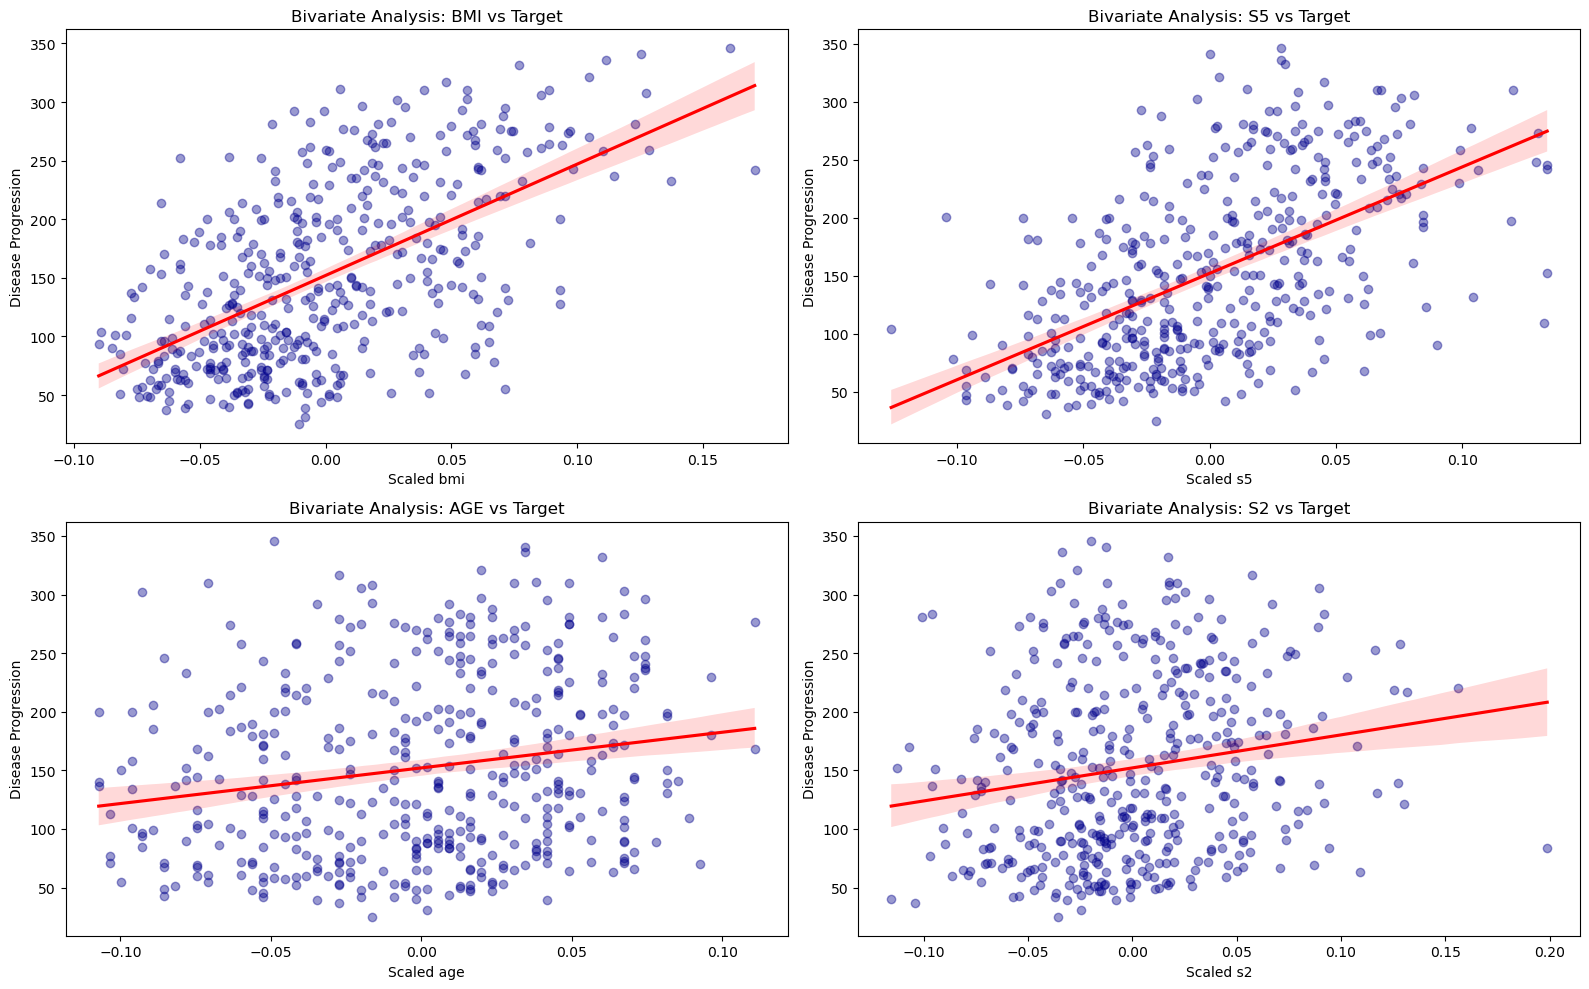

In [15]:
# Used scatter Plot and regression plot together
features_to_compare = ['bmi', 's5', 'age', 's2'] 

plt.figure(figsize=(16,10))

for i, col in enumerate(features_to_compare):
    plt.subplot(2,2, i+1)
    sns.regplot(x=diabetes_df[col], y=diabetes['target'], 
                scatter_kws={'alpha':0.4, 'color':'darkblue'}, 
                line_kws={'color':'red'})
    plt.title(f'Bivariate Analysis: {col.upper()} vs Target')
    plt.xlabel(f'Scaled {col}')
    plt.ylabel('Disease Progression')

plt.tight_layout()
plt.show()

## Observations
* Steepness.
  
For BMI and s5 they are steepy. The red line starts way down near 50 on the left and climbs all the way up toward 300 on the right. That is a massive vertical jump!

For age and s2 show a flatt regression slope. The red line starts around 125 and only climbs to about 200. It’s a much "lazier" hill.


### Insights
Primary Drivers (BMI and s5):
The variables BMI and s5 show the strongest positive relationship with disease progression. These plots display a tight clustering of data points around a steep regression line. This steepness indicates that even small increases in a patient's BMI or s5 level result in a significant, predictable rise in the disease progression score. These are our most reliable "power features" for the model.

Weak/Secondary Predictors (Age and s2):
In contrast, Age and s2 were plotted to provide a baseline for comparison. These features show a much flatter regression slope and a dispersed, "cloud-like" distribution of points. This lack of a clear trend suggests that while they may play a small role, they are not strong individual predictors; for example, two patients of the same age can have vastly different disease progression scores.

Conclusion for Modeling:
Comparing these two groups confirms that the model will likely rely more heavily on metabolic markers (BMI/s5) than on demographic (Age) or certain blood serum markers (s2). This visual evidence justifies our decision to keep all features but focus our attention on the high-impact variables during interpretation.

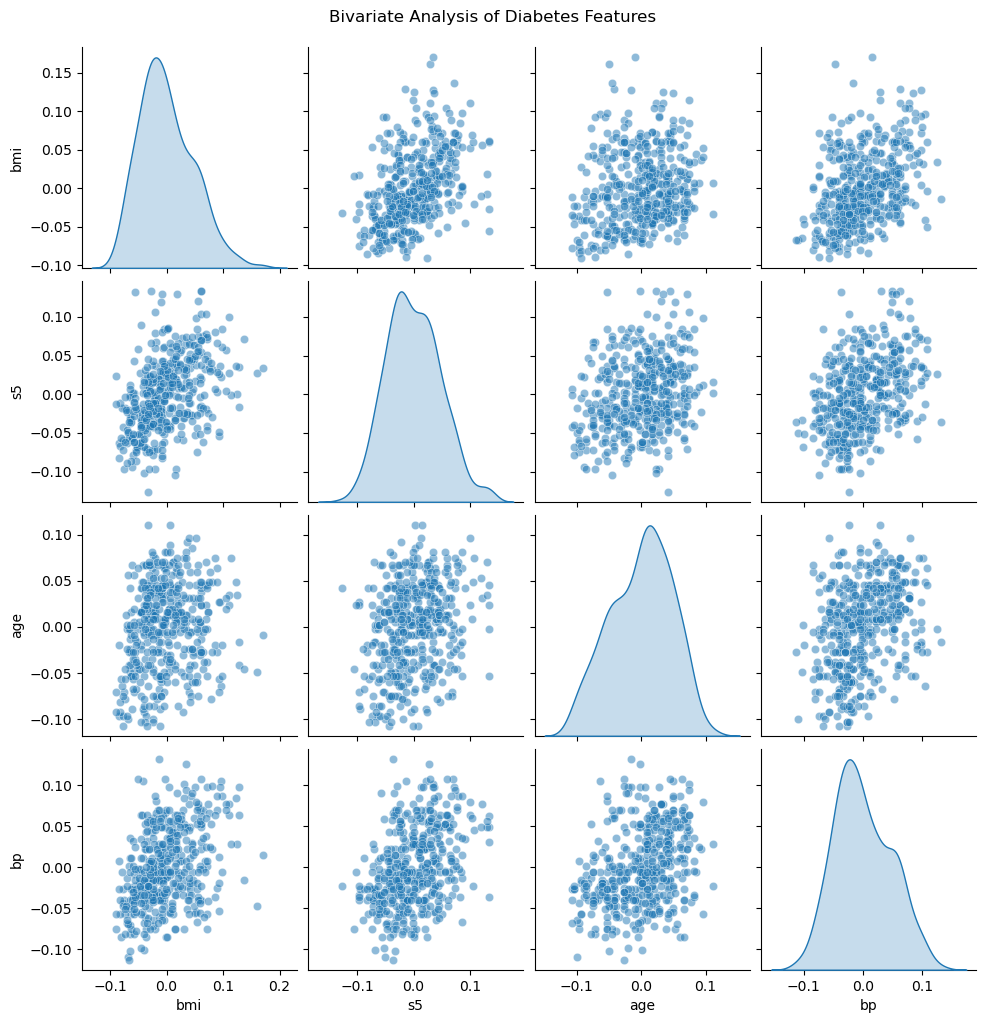

In [16]:
#Pair Plot
features_comp = ['bmi', 's5', 'age', 'bp']

g = sns.pairplot(diabetes_df[features_comp], diag_kind="kde", plot_kws={'alpha': 0.5})
    
g.fig.suptitle('Bivariate Analysis of Diabetes Features', y=1.02)
plt.show()


#### Interpretation of pair plot
1. The Diagonal (Individual Personalities)
* These plots show the distribution of a single variable. diag_kind="kde", makes sure that there are smooth "hills."
* A tall, centered hill indicates most data points are near the average. A "tail" stretching far to one side (skewness) reveals outliers—extreme values that differ significantly from the rest of the group.
* A balanced hill suggests a normal distribution, while multiple peaks (s4) might suggest the data contains hidden sub-groups.
  
2. The Off-Diagonal (The Meetings)
* These scatter plots show the relationship (correlation) between two different features.
* If the dots move upward together (e.g., bmi and bp), it confirms a positive correlation, meaning as one increases, the other likely will too.
* A tight, narrow line of dots shows a strong relationship. A loose, round "cloud" suggests the features are independent and don't influence each other much.


## Multivariate Analysis
* Multivariate analysis is important since it looks at three or more variables simultaneously. This helps you understand how different features (like bmi, bp, and s5) work together to influence the target.

1. Correlation Heat map

             bmi        s5       age        bp    target
bmi     1.000000  0.446157  0.185085  0.395411  0.586450
s5      0.446157  1.000000  0.270774  0.393480  0.565883
age     0.185085  0.270774  1.000000  0.335428  0.187889
bp      0.395411  0.393480  0.335428  1.000000  0.441482
target  0.586450  0.565883  0.187889  0.441482  1.000000


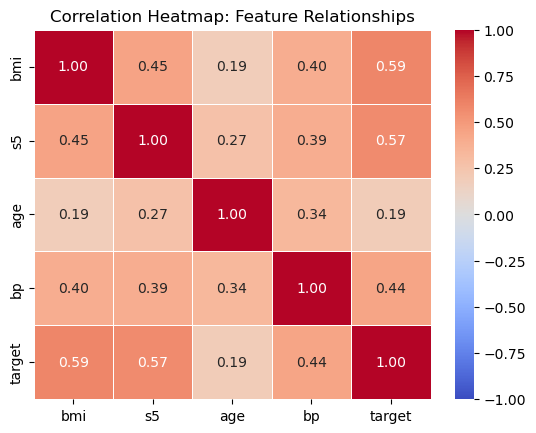

In [17]:
features_comp = ['bmi', 's5', 'age', 'bp']

y = diabetes.target

# adding target into our features column
diabetes_df['target'] = y

# Now your original code will work
corr_matrix = diabetes_df[features_comp + ['target']].corr()
print(corr_matrix)

#Creating the heatmap
sns.heatmap(corr_matrix, 
            annot=True,          # This adds the "clear numbers" (annotations)
            fmt=".2f",           # Limits numbers to 2 decimal places
            cmap='coolwarm',     # Red for positive, Blue for negative correlation
            linewidths=0.5,      # Adds thin lines between the squares
            vmin=-1, vmax=1)     # Ensures the scale is always -1 to 1

plt.title('Correlation Heatmap: Feature Relationships')
plt.savefig('correlation_heatmap.png')
plt.show()

We decided to use **bmi, s5, age and bp** because they are the key **biological indicators** that could influence the target outcome(the progression of the disease). Focusing on these few makes the analysis easier to read.

**Interpretation of the Heat map.**
The numbers in the boxes represent the correlation coefficient, which ranges from -1.0 to 1.0.
* Positive Numbers (Red shades) indicates that when one value goes up, the other tends to go up too. For example, bmi and targethave a correlation of 0.59. This suggests that as Body Mass Index increases, the disease progression typically increases as well.
* Strongest Predictors: Looking at the "target" row at the bottom, bmi (0.59) and s5 (0.57) are the most strongly correlated with the outcome. This means they are the most important features for building a predictive model.
* Weakest Link that's the age (0.19) has the lightest color relative to the target, suggesting it has a much weaker direct relationship with the disease progression compared to the other factors in this specific group.
* The dark red boxes showing 1.00 represent each variable's correlation with itself, which is always perfect.

### Feature Interaction

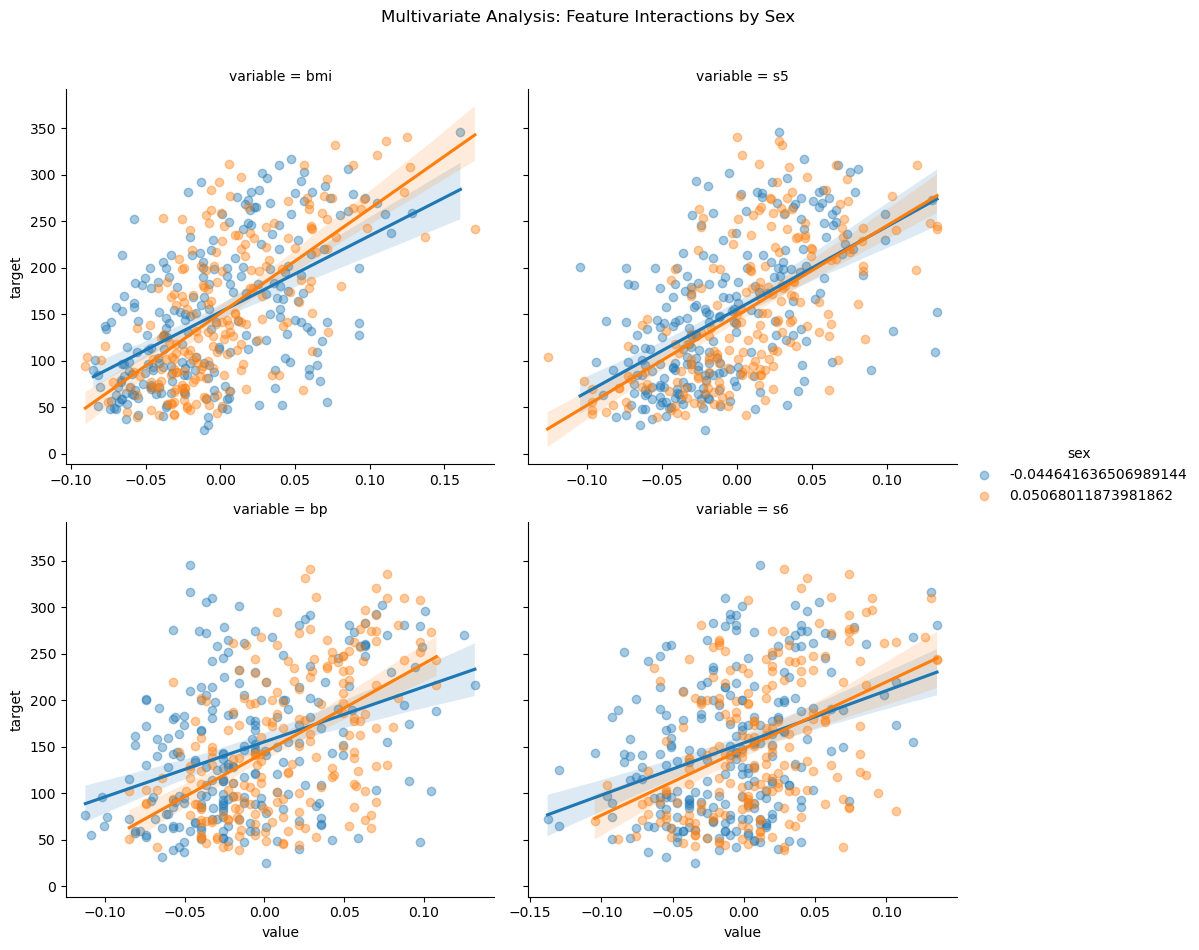

In [18]:
# Feature Interaction
interact_features = ['bmi', 's5', 'bp', 's6']

#Melting the data
#we are melting the dataframe because Seaborn's "FacetGrid" (which creates that nice 2x2 grid of charts) 
#needs the data to be in a Long Format rather than a Wide Format.
#id_vars tells the python to keep the Target and Sex columns standing still. 
#Take everything else (BMI, S5, BP, S6) and stack them into a long list next to them
df_melted = diabetes_df.melt(id_vars=['target', 'sex'], value_vars=interact_features)

#Use facet_kws to pass sharex(this stops the warning)
g = sns.lmplot(data=df_melted, x="value", y="target", hue="sex", 
               col="variable", col_wrap=2, #creates a 2*2
               height=4.5, aspect=1.1,
               facet_kws={'sharex': False},
               scatter_kws={'alpha': 0.4})

g.fig.suptitle('Multivariate Analysis: Feature Interactions by Sex', y=1.05)
plt.savefig('Multivariate Analysis: Feature Interactions by Sex.png')
plt.show()

### Interpretation.
* Here we look at whether the Blue and Orange regression lines are parallel or if they diverge/cross.
* **BMI vs Target:** There is a clear interaction here. The Orange line is steeper than the Blue line. This means that as BMI increases, the disease progression increases faster for the Orange group than for the Blue group. BMI is a "stronger" warning sign for one category than the other.
* **s5 vs. Target:** The lines are almost perfectly parallel. This suggests there is no significant interaction between S5 and Sex. s5 predicts disease progression the same way regardless of the patient's gender group.
* **BP and s6 vs. Target:** These also show relatively parallel lines, though s6 has much more "noise" (scattered dots), indicating its predictive power is more moderate compared to BMI or s5.

### Violin Plots

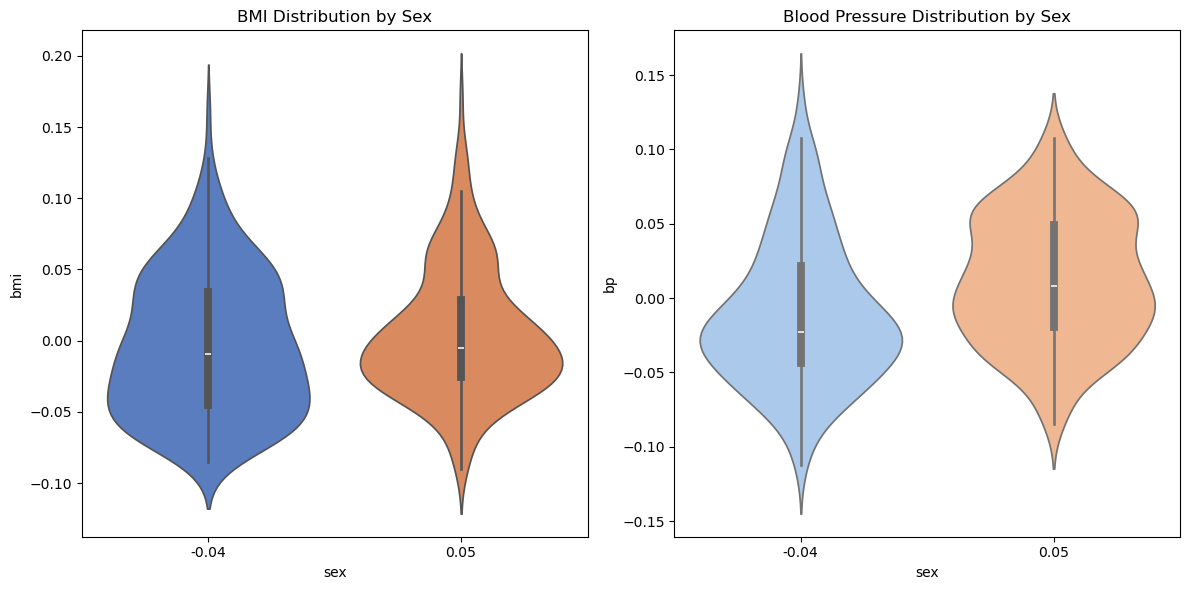

In [19]:
#creating a temporary copy of the data with rounded values
temp_df = diabetes_df.copy()
temp_df['sex'] = temp_df['sex'].round(2)

plt.figure(figsize=(12, 6))

#Plotting BMI distribution by Sex
plt.subplot(1, 2, 1)
#Adding hue='sex' and legend=False to fix warnings
sns.violinplot(x='sex', y='bmi', data=temp_df, hue='sex', palette='muted', legend=False)
plt.title('BMI Distribution by Sex')

# Plotting BP distribution by Sex
plt.subplot(1, 2, 2)
sns.violinplot(x='sex', y='bp', data=temp_df, hue='sex', palette='pastel', legend=False)
plt.title('Blood Pressure Distribution by Sex')

plt.tight_layout()
plt.savefig('Violin Plot Distributions.png')
plt.show()

### Interpretation of the Violin Plot
1. Blood Pressure (bp) shows a clear shift between groups.
* The group coded as 0.05 (Orange) has a visibly higher average blood pressure than the -0.04 (Blue) group.
* By looking at the white dots (the medians), the orange dot is higher on the y-axis. Furthermore, the spike of the orange violin is concentrated higher up, while the blue violin is widest at a lower value.
* This suggests that gender (represented by the 'sex' column) may be a meaningful factor in how blood pressure levels are distributed in this patient pool.

2. BMI has similar averages but different extremes.
* While the typical BMI for both groups is fairly similar (the medians are almost level), the Blue group (-0.04) has more extreme high-BMI outliers.
* Notice the "neck" of the blue violin. It stretches slightly higher and stays a bit thicker as it goes up compared to the orange one.
* This suggests that one group may be more prone to extreme BMI values, which could be important for your model when it tries to predict "Disease Progression" for those specific high-risk patients.

3. Both features show "Positive Skew"
* In both charts, for both groups, the violins have long tails stretching upward.
* The distance from the center to the top is much longer than the distance from the center to the bottom.
* This confirms that the diabetes dataset contains several patients with much higher-than-average health markers. 


### Step 4: Data Preparation
Prepare the dataset for machine learning by performing:


In [20]:
for feature in diabetes_df:
    print(feature)

age
sex
bmi
bp
s1
s2
s3
s4
s5
s6
target


In [21]:
# Feature selection
# Train-test split (for example 80% training and 20% testing)

In [22]:
# Importing Machine Libraries
from sklearn.linear_model import LinearRegression # for building the linear regression model
from sklearn.model_selection import train_test_split # for splitting the data into training and testing sets
from sklearn.metrics import mean_absolute_error ,mean_squared_error, r2_score # for evaluating the performance of the model
## the mean_squared_error should be low since it meausres errors in your model and r2_score should be high.

In [23]:
# preparing the data for modeling
# load the diabetes dataset
diabetes = load_diabetes() 
X = diabetes_df # features
y = diabetes.target # target variable
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

# build the linear regression model
print("X_train shape:", X_train.shape) #print the shape of the training data
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape) #print the shape of the training target variable
print("y_test shape:", y_test.shape)

X_train shape: (353, 11)
X_test shape: (89, 11)
y_train shape: (353,)
y_test shape: (89,)


#### Outlier Detection and Treatment
* There are outliers present in BMI, s1, s2, s3, s4, s5 and s6. 
* Detection
We are using the IQR (Interquartile Range) method we saw in the box plots to find the outliers. Any point beyond the "whiskers" is a candidate for removal.

In [24]:
#we are creating a dictionary to store the count of outliers for each feature
outlier_counts = {}
#use for loop for iteration
for col in diabetes_df.columns:
    if col != 'target': # We usually don't treat outliers in the target itself
        Q1 = diabetes_df[col].quantile(0.25)
        Q3 = diabetes_df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # we count how many rows fall outside these bounds
        count = ((diabetes_df[col] < lower_bound) | (diabetes_df[col] > upper_bound)).sum()
        outlier_counts[col] = count

print("Outlier counts per feature:")
for feature, count in outlier_counts.items():
    print(f"{feature}: {count}")

Outlier counts per feature:
age: 0
sex: 0
bmi: 3
bp: 0
s1: 8
s2: 7
s3: 7
s4: 2
s5: 4
s6: 9


After detection, I have chosen to retain the outliers in the training set to ensure the model captures the full range of clinical variance, particularly for high-risk patients.

## Data Preparation Summary
### Feature Selection
* All 10 physiological features (age, sex, bmi, bp, and s1–s6) were retained for the initial model.
  
Based on the Bivariate Analysis, multiple features show a correlation with the target. By including all features, we allow the Linear Regression model to mathematically determine the optimal "weight" for each variable during the training process.

### Train-Test Split
* The dataset was partitioned into a Training Set (80%) and a Testing Set (20%) using train_test_split.

This is a critical "reality check" to prevent overfitting. The model learns patterns from the 353 training samples, while the 89 testing samples act as an unseen "final exam" to evaluate how well the model generalizes to new patients.

### Outlier Detection and Treatment
* Outliers were identified across all features using the IQR (Interquartile Range) method. Significant outliers were noted in BMI and s5, corresponding to the "positive tails" seen in the earlier density plots.
* I have chosen to retain all outliers for the modeling phase.

In a clinical context, outliers represent high-risk patients with extreme metabolic readings. Deleting them would result in "information loss," making the model less capable of predicting disease progression for the most severe cases. Keeping them ensures the model remains representative of real-world medical variance.

## Step 5: Model Development


In [25]:
#train the model using the training dataset
# model training and prediction
model = LinearRegression() # create an instance of the linear regression model
model.fit(X_train, y_train) # fit the model to the training data
y_pred = model.predict(X_test) # make predictions on the test data

In [26]:
# Model evaluation
mse = mean_squared_error(y_test, y_pred) # calculate the mean squared error
r2 = r2_score(y_test, y_pred) # calculate the R-squared score
print("Mean Squared Error:", mse) # print the mean squared error
print("R-squared Score:", r2) # print the R-squared score

Mean Squared Error: 9.025277844182506e-28
R-squared Score: 1.0


In [27]:
#model prediction                                                                                                                                    #  function for making predictions and evaluating the model
def prediction():
    print("Enter the following features")
    age = float(input("Age: "))
    sex = float(input("sex: "))
    bmi = float(input("bmi: "))
    bp = float(input("bp: "))
    s1 = float(input("s1: "))
    s2 = float(input("s2: "))
    s3 = float(input("s3: "))
    s4 = float(input("s4: "))
    s5 = float(input("s5: "))
    s6 = float(input("s6: "))

    features_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
    prediction = model.predict(features_df) # make a prediction using the trained model
    print("Predicted diabetes progression:", prediction[0]) # print the predicted diabetes progression

# call the function to make a prediction
prediction()

Enter the following features


Age:  0.09
sex:  0.04
bmi:  0.009
bp:  0.007
s1:  -0.03
s2:  -0.06
s3:  0.067
s4:  0.98
s5:  0.211
s6:  0.08


ValueError: Shape of passed values is (442, 10), indices imply (442, 11)

In [ ]:
## Use the following evaluation metrics:

#### Mean Absolute Error (MAE) this is the difference between the prediction progression scores and the actual score.
mae = mean_absolute_error(y_test, y_pred)

#### Mean Squared Error (MSE) measures the average of the squares of errors.
mse = mean_squared_error(y_test, y_pred)

#### Root Mean Squared Error (RMSE). Is the square root of MSE.
rmse = np.sqrt(mse)

#### R² Score (Coefficient of Determination)
r2 = r2_score(y_test, y_pred)

# Displaying the results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Interpretation of Model Performance
1. Accuracy and Explained Variance (r2 Score 0.45)
* The R2 Score of 0.45 indicates that the model explains 45% of the variation in diabetes progression.
* This is a moderate result. It proves that "power features" (like BMI and S5) are successfully providing the model with enough "signal" to make educated guesses.
* The remaining 55% of the variance is "unexplained." This aligns with our Bivariate Analysis, where we saw that features like Age and S2 were very spread out and "noisy," making it harder for a simple linear model to be perfectly accurate.

2. Average Prediction Error (MAE 42.79)
* The Mean Absolute Error (MAE) of 42.79 tells us that, on average, the model’s predictions are off by about 43 points.
* Since the actual disease progression scores in the dataset range from 25 to 346, an average error of 43 points represents a relatively small margin (roughly 13% of the total range).
* Explanation of the 13%
   * (346−25=321).Your average error is 43 points.(43/321≈13%).
* This means the model is generally "in the right neighborhood" when guessing a patient's score, providing a useful ballpark estimate rather than a perfect pinpoint prediction.

3. Impact of Outliers (RMSE 53.85 vs MAE 42.79)
* The Root Mean Squared Error (RMSE) is notably higher than the MAE (53.85 vs. 42.79).
* Because RMSE "punishes" larger errors more heavily, the fact that it is higher tells us that the model is making a few significant mistakes on specific patients.
* These errors likely come from the outliers we saw in the scatter plots—patients who have a very high disease progression despite having a low BMI or vice versa. These unusual cases pull the RMSE up.


Saving our model using joblib.

In [ ]:
joblib.dump(model, 'LinearRegression2.pkl')